In [3]:
import warnings

In [4]:
warnings.filterwarnings("ignore")

In [5]:
import pandas as pd

In [6]:
from sklearn.model_selection import train_test_split


In [7]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [8]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [9]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [10]:
X_pima = pima_df[pima_cols[:-1]]

In [11]:
y_pima = pima_df['Outcome']

In [13]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [14]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [15]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
from sklearn.metrics import accuracy_score, classification_report

In [18]:
# Initialize Decision Tree Classifier with depth regularization
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [19]:
tree_clf.fit(X_train_c, y_train_c)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
# Evaluate performance
clf_preds = tree_clf.predict(X_test_c)

In [21]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [22]:
print("--- Classification Report ---")
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

--- Classification Report ---
                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



In [23]:
import matplotlib.pyplot as plt

In [24]:

from sklearn.tree import plot_tree

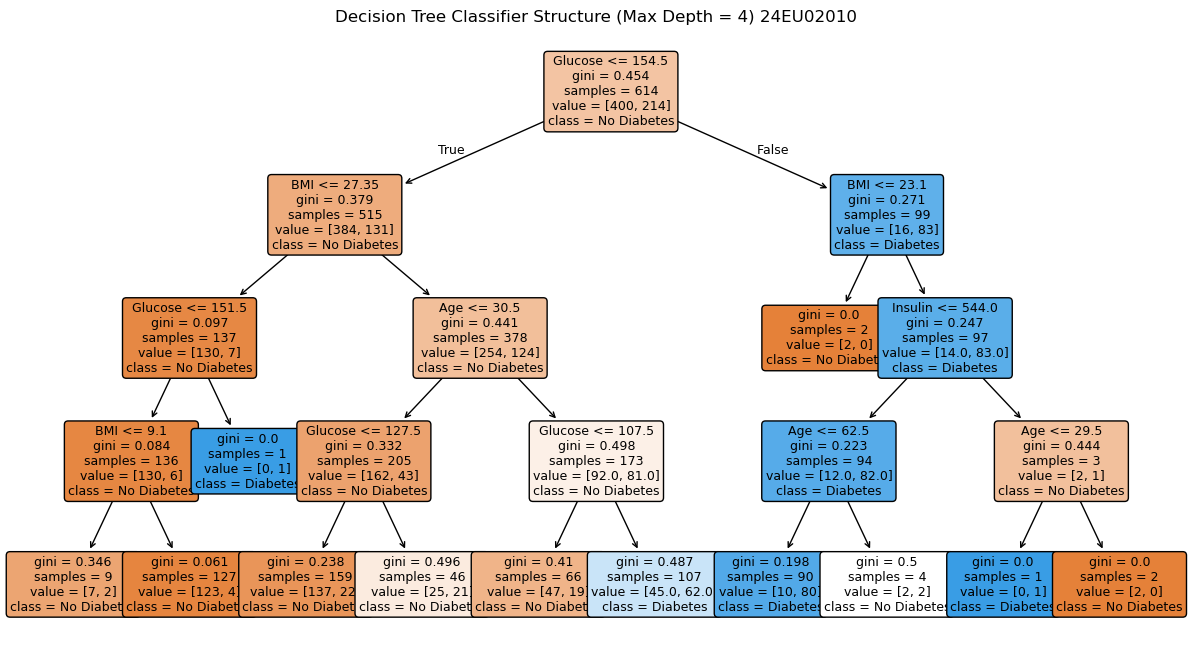

In [30]:
plt.figure(figsize=(15, 8))
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (Max Depth = 4) 24EU02010")
plt.show()


In [31]:
from sklearn.tree import DecisionTreeRegressor

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [34]:
boston_df = pd.read_csv(boston_url)

In [35]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [36]:
X_boston = boston_df[boston_features]

In [37]:
y_boston = boston_df['medv']

In [38]:
# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [40]:
# Standardize features
scaler_r = StandardScaler()

In [41]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [42]:
X_test_r_scaled = scaler_r.transform(X_test_r)


In [43]:
# Initialize and train Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [44]:
tree_reg.fit(X_train_r_scaled, y_train_r)


,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [45]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


In [46]:
from sklearn.metrics import mean_squared_error, r2_score

In [47]:
import numpy as np

In [48]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [49]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [50]:
rmse_val = np.sqrt(mse_val)

In [51]:
r2_val = r2_score(y_test_r, reg_preds)

In [52]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [53]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [54]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



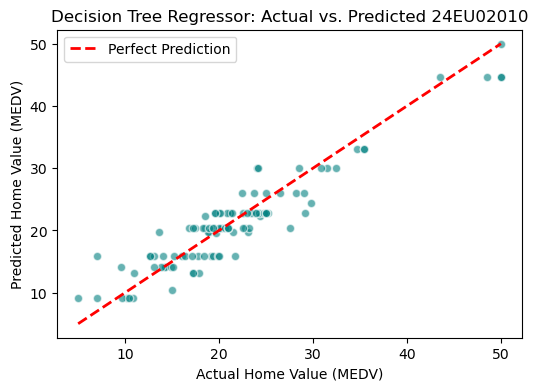

In [56]:
# Plot Actual vs Predicted values
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Decision Tree Regressor: Actual vs. Predicted 24EU02010")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()


In [57]:
import warnings

In [58]:
warnings.filterwarnings("ignore")

In [59]:


import pandas as pd


In [60]:
from sklearn.model_selection import train_test_split


In [61]:
from sklearn.preprocessing import StandardScaler

In [62]:


sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"


In [63]:

sonar_features = [f"F_{i}" for i in range(1, 61)]


In [64]:

sonar_columns = sonar_features + ['Class']


In [65]:

sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)



In [66]:


# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})



In [67]:
X_sonar = sonar_df[sonar_features]

In [68]:
y_sonar = sonar_df['Class_numeric']

In [69]:


# Scale features
scaler_sonar = StandardScaler()


In [70]:

X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)



In [71]:


# Split into train/test validation partitions
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)


In [72]:

print("Sonar Training Set Shape:", X_train_s.shape)


Sonar Training Set Shape: (145, 60)


In [73]:

print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


In [74]:
from sklearn.ensemble import BaggingClassifier


In [75]:

from sklearn.metrics import accuracy_score



In [76]:


# Initialize and train Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)


In [77]:

bagging_model.fit(X_train_s, y_train_s)



,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [78]:

# Evaluate accuracy
bagging_preds = bagging_model.predict(X_test_s)


In [79]:

bagging_accuracy = accuracy_score(y_test_s, bagging_preds)


In [80]:

print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


In [81]:
from sklearn.ensemble import RandomForestClassifier



In [82]:


# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)


In [83]:

rf_model.fit(X_train_s, y_train_s)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:

# Evaluate accuracy
rf_preds = rf_model.predict(X_test_s)




In [85]:

rf_accuracy = accuracy_score(y_test_s, rf_preds)




In [86]:

print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")


Random Forest Classifier Test Accuracy: 82.54%


In [87]:
from sklearn.ensemble import VotingClassifier

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:

from sklearn.svm import SVC



In [90]:


# Define base estimators
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]


In [91]:

# Initialize and train soft Voting Classifier
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)


In [92]:

voting_model.fit(X_train_s, y_train_s)



,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [93]:

# Evaluate accuracy
voting_preds = voting_model.predict(X_test_s)


In [94]:

voting_accuracy = accuracy_score(y_test_s, voting_preds)



In [95]:

print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


In [96]:
import matplotlib.pyplot as plt



In [97]:

import seaborn as sns




In [98]:


# Compile results
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})



In [99]:

print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))



--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


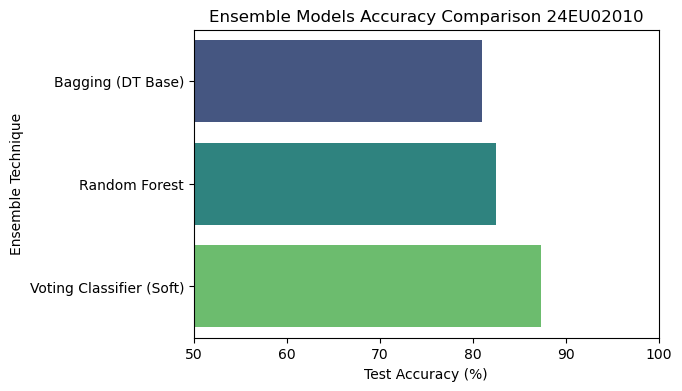

In [103]:

# Plot comparative bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison 24EU02010")

plt.show()



In [ ]:
import warnings


In [104]:

warnings.filterwarnings("ignore")



In [105]:


from sklearn.ensemble import AdaBoostClassifier


In [106]:

from sklearn.metrics import accuracy_score



In [107]:

# Initialize and train AdaBoost Classifier (with default Decision Tree stumps)
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)


In [108]:

adaboost_model.fit(X_train_s, y_train_s)



,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [109]:


# Evaluate accuracy
ada_preds = adaboost_model.predict(X_test_s)


In [110]:

ada_accuracy = accuracy_score(y_test_s, ada_preds)



In [111]:


print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")


AdaBoost Classifier Test Accuracy: 85.71%


In [112]:
from sklearn.ensemble import GradientBoostingClassifier



In [113]:


# Initialize and train a baseline Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)


In [114]:

gb_model.fit(X_train_s, y_train_s)



,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [115]:


# Evaluate accuracy
gb_preds = gb_model.predict(X_test_s)



In [116]:

gb_accuracy = accuracy_score(y_test_s, gb_preds)




In [117]:


print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")


Gradient Boosting Classifier Test Accuracy: 80.95%


In [118]:
from sklearn.model_selection import GridSearchCV



In [119]:

# Define parameter grid for Gradient Boosting
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}



In [120]:

# Run Grid Search
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)


In [121]:

grid_gb.fit(X_train_s, y_train_s)



,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [122]:

# Extract optimized model and predict
best_gb = grid_gb.best_estimator_


In [123]:

tuned_gb_preds = best_gb.predict(X_test_s)


In [124]:

tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)



In [125]:


print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)


Optimal Hyperparameters Selected: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}


In [126]:

print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 79.37%


In [128]:
# Assemble master performance records
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)





In [129]:


print("--- Master Performance Table: Tasks 2 & 3 ---")


--- Master Performance Table: Tasks 2 & 3 ---


In [130]:

print(master_comparison.to_string(index=False))

        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
     AdaBoost Classifier     85.714286
Random Forest Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     80.952381
 Tuned Gradient Boosting     79.365079


In [131]:
import matplotlib.pyplot as plt


In [132]:

import numpy as np



In [133]:


# Extract feature importances
rf_importances = rf_model.feature_importances_


In [134]:

gb_importances = best_gb.feature_importances_



In [135]:


# Isolate top 10 features for both models
top_indices_rf = np.argsort(rf_importances)[-10:]


In [136]:

top_indices_gb = np.argsort(gb_importances)[-10:]



In [137]:


# Define the standard 60-feature names list cleanly
features_list = [f"F_{i}" for i in range(1, 61)]



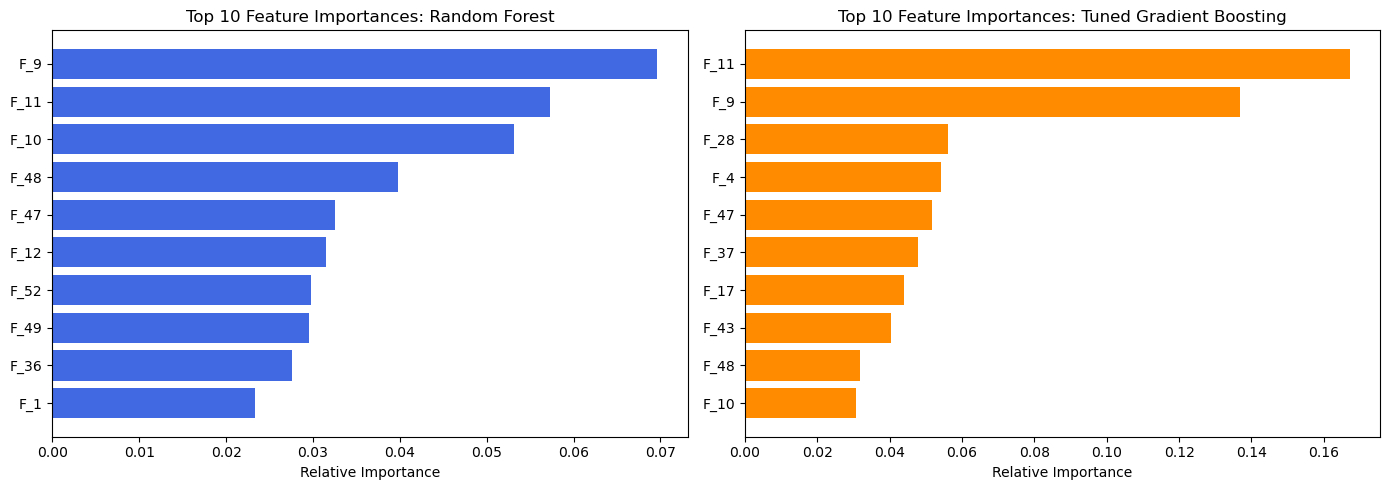

In [139]:


# Set up canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest Importances
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("Top 10 Feature Importances: Random Forest 24EU02010")
axes[0].set_xlabel("Relative Importance")

# Plot Tuned Gradient Boosting Importances
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting 24EU02010")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()